# Section 6 — Empirical Study

This notebook generates the empirical Meuse results reported in Section 6 of the paper.

It contains two deliberately separate empirical protocols:

- **Table 8:** descriptive local GR diagnostics for the 120 training locations from a fixed-seed 120/35 split.
- **Tables 9–10:** five-fold cross-validation and benchmark-side conditioning diagnostics using all 155 Meuse locations.

The notebook also generates the two GR diagnostic figures used in the trade-off interpretation subsection.

The empirical objective is not universal predictive superiority. The notebook is organized around the paper's comparison of prediction, residual spatial autocorrelation, runtime, local conditioning, and diagnostic inspectability.


## Reproducibility environment

The manuscript replication target is `gimbal-regression==0.1.7`.

Runtime is environment-specific, so it is recorded but not treated as a deterministic replication target. The numerical accuracy and conditioning outputs are checked separately from elapsed time.


In [1]:
from importlib.metadata import version
from pathlib import Path
import os
import platform
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pyproj import Transformer

import grpy
from grpy import GimbalRegression
import grpy.benchmark as gr_benchmark

GR_VERSION = version("gimbal-regression")
MODULE_VERSION = getattr(grpy, "__version__", None)

print("gimbal-regression distribution:", GR_VERSION)
print("grpy.__version__:", MODULE_VERSION)
print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("Machine:", platform.machine())

assert GR_VERSION == "0.1.7"

if MODULE_VERSION != GR_VERSION:
    print(
        "WARNING: grpy.__version__ does not match distribution metadata. "
        "Fix src/grpy/__init__.py before the final release."
    )

OUTPUT_DIR = Path("section6_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def display_3(df, *, integer_columns=()):
    fmt = {}
    for col in df.columns:
        if col in integer_columns:
            fmt[col] = "{:.0f}"
        elif pd.api.types.is_numeric_dtype(df[col]):
            fmt[col] = "{:.3f}"
    display(df.style.format(fmt))


gimbal-regression distribution: 0.1.7
grpy.__version__: 0.1.7
Python: 3.12.3
Platform: Linux-6.8.0-106-generic-x86_64-with-glibc2.39
Machine: x86_64


## 6.1 Study design and evaluation criteria

The empirical study uses raw cadmium concentration as the response and lead as the primary covariate.

The benchmark compares:

- GR
- GR with post-estimation residual-KNN correction
- OLS
- local ridge regression (LRR)
- geographically weighted regression (GWR)
- multiscale GWR (MGWR)
- regression kriging (RK)
- coordinate-augmented random forest (RF-XY)

Reported benchmark outcomes are RMSE, MAE, \(R^2\), residual Moran's \(I\), and elapsed runtime.

For GR, LRR, GWR, and MGWR, Section 6 also compares the standardized local two-column conditioning diagnostic generated by the benchmark implementation. For LRR, the ridge-adjusted diagnostic is used.


## 6.2 Meuse dataset

The Meuse dataset contains 155 sampled locations. The source file must contain the original RD New projected coordinates (`x`, `y`) together with `cadmium` and `lead`.

Coordinates are converted from **EPSG:28992** to **EPSG:4326** because the GR interface uses latitude and longitude.


In [2]:
DATA_PATH = Path("../data/meuse.csv")
assert DATA_PATH.exists(), f"Meuse data not found: {DATA_PATH.resolve()}"

df = pd.read_csv(DATA_PATH)

required = {"x", "y", "cadmium", "lead"}
missing = required.difference(df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"
assert len(df) == 155

transformer = Transformer.from_crs(
    "EPSG:28992",
    "EPSG:4326",
    always_xy=True,
)
lon, lat = transformer.transform(
    df["x"].to_numpy(dtype=float),
    df["y"].to_numpy(dtype=float),
)

df = df.copy()
df["lon"] = lon
df["lat"] = lat

print("Rows:", len(df))
print("Unique projected coordinates:", df[["x", "y"]].drop_duplicates().shape[0])
print("Cadmium sum:", df["cadmium"].sum())
print("Lead sum:", df["lead"].sum())

display(df[["x", "y", "lat", "lon", "cadmium", "lead"]].head())


Rows: 155
Unique projected coordinates: 155
Cadmium sum: 503.09999999999997
Lead sum: 23771


,x,y,lat,lon,cadmium,lead
0,181072,333611,50.991562,5.758536,11.7,299
1,181025,333558,50.991088,5.757863,8.6,277
2,181165,333537,50.990893,5.759855,6.5,199
3,181298,333484,50.990410,5.761746,2.6,116
4,181307,333330,50.989026,5.761863,2.8,117


### 6.2.1 Local GR diagnostics — Table 8

A fixed sample of 120 locations is drawn from the 155 observations using Python's `random` module with seed 19. These 120 observations form the training pool for the descriptive local GR analysis.

Configuration:

- \(K=30\)
- \(h=2000\) m
- \(\gamma=1\)
- normalized-distance scale \(u=2000\) m
- \(n_0=20\)
- \(n_{\min}=4\)

Neighborhoods are constructed only within the 120-location training pool. Table 8 is an in-sample target-level diagnostic summary, not an out-of-sample performance table.


In [3]:
random.seed(19)
ixs = random.sample(range(df.shape[0]), 120)

meuse_train = (
    df.loc[ixs, ["lat", "lon", "cadmium", "lead"]]
    .dropna()
    .reset_index(drop=True)
)

# Fixed-sample fingerprints.
assert len(meuse_train) == 120
assert np.isclose(meuse_train["cadmium"].sum(), 421.3)
assert np.isclose(meuse_train["lead"].sum(), 19183.0)

print("Training rows:", len(meuse_train))
print("Cadmium sum:", meuse_train["cadmium"].sum())
print("Lead sum:", meuse_train["lead"].sum())


Training rows: 120
Cadmium sum: 421.3
Lead sum: 19183


In [4]:
gr_local = GimbalRegression(
    K=30,
    h_m=2000.0,
    gamma=1.0,
    n0=20.0,
    min_neff=4.0,
    u_scale=2000.0,
    use_ess=True,
    res_weight_mode="distance",
    compute_local_moran=False,
).fit(
    y=meuse_train["cadmium"].to_numpy(dtype=np.float64),
    x=meuse_train["lead"].to_numpy(dtype=np.float64),
    lat=meuse_train["lat"].to_numpy(dtype=np.float64),
    lon=meuse_train["lon"].to_numpy(dtype=np.float64),
)

results8 = gr_local.results_.copy()

assert len(results8) == 120
assert getattr(gr_local, "n_errors_", 0) == 0

required_results = {
    "phi", "r_phi", "eta", "neff_post",
    "R2", "RMSE", "B0", "B1", "Bz",
}
missing_results = required_results.difference(results8.columns)
assert not missing_results, (
    "The installed package does not expose the canonical Section 6 result "
    f"columns: {sorted(missing_results)}"
)

if "uniform_flag" in results8.columns:
    assert int(pd.to_numeric(results8["uniform_flag"], errors="coerce").fillna(0).sum()) == 0

print("Local fits:", len(results8))
print("Local fit errors:", getattr(gr_local, "n_errors_", 0))


Local fits: 120
Local fit errors: 0


In [5]:
table8_vars = {
    "phi": "phi",
    "r_phi": "r_phi",
    "eta": "eta",
    "ESS": "neff_post",
    "R2": "R2",
    "RMSE": "RMSE",
    "B0": "B0",
    "B1": "B1",
    "Bz": "Bz"
}

rows8 = []

for label, col in table8_vars.items():
    s = pd.to_numeric(results8[col], errors="coerce").dropna()
    rows8.append({
        "Statistic": label,
        "Mean": s.mean(),
        "SD": s.std(ddof=1),
        "Min": s.min(),
        "Median": s.median(),
        "Max": s.max(),
    })

table8 = pd.DataFrame(rows8)

display_3(table8)

table8.to_csv(
    OUTPUT_DIR / "table8_meuse_local_diagnostics.csv",
    index=False,
    float_format="%.6f",
)


,Statistic,Mean,SD,Min,Median,Max
0,phi,0.503,1.841,-3.070,0.270,3.016
1,r_phi,0.432,0.210,0.019,0.416,0.892
2,eta,1.459,0.417,1.018,1.340,2.996
3,ESS,29.953,0.057,29.462,29.966,29.996
4,R2,0.763,0.089,0.519,0.769,0.935
5,RMSE,1.620,0.602,0.309,1.528,2.731
6,B0,-1.267,1.677,-4.916,-1.462,3.973
7,B1,0.029,0.011,0.014,0.025,0.052
8,Bz,0.819,5.364,-13.930,1.431,14.691


The corrected pre-fallback ESS is close to \(K=30\) at most targets, indicating limited concentration in the directional modulation weights under this configuration. This observation is descriptive and does not by itself establish full rank or favorable local conditioning.


### 6.2.2 Benchmark results — Table 9

The benchmark uses all 155 Meuse locations under conventional five-fold random cross-validation with seed 42.

The local-regression baseline protocol uses fold-specific covariate standardization and the stable bandwidth-search configuration represented by `reproduce_rank_deficiency=False`.

The deterministic replication targets are RMSE, MAE, \(R^2\), and Moran's \(I\). Runtime is reported from the current execution environment and is therefore not asserted.


In [6]:
df_benchmark = pd.DataFrame({
    "lat": df["lat"].to_numpy(dtype=float),
    "lon": df["lon"].to_numpy(dtype=float),
    "X": df["lead"].to_numpy(dtype=float),
    "Y": df["cadmium"].to_numpy(dtype=float),
})

assert len(df_benchmark) == 155

metrics_df, preds_df, diag_df = gr_benchmark.run_benchmark(
    df_benchmark,
    cv_mode="random",
    n_splits=5,
    seed=42,
    reproduce_rank_deficiency=False,
    gr_K=30,
    gr_h_m=2000.0,
    gr_gamma=1.0,
    gr_n0=20.0,
    gr_min_neff=4.0,
    gr_u_scale=2000.0,
)


Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

In [7]:
model_order = [
    "GR",
    "GR+Residual-KNN",
    "OLS",
    "LRR",
    "GWR",
    "MGWR",
    "RK",
    "RF-XY",
]

table9 = (
    metrics_df.loc[
        metrics_df["fold"].eq("MEAN"),
        ["model", "RMSE", "MAE", "R2", "Moran_I", "time_sec"],
    ]
    .set_index("model")
    .loc[model_order]
    .reset_index()
)

table9_display = table9.rename(columns={
    "model": "Model",
    "R2": "R²",
    "Moran_I": "Moran's I",
    "time_sec": "Time (s)",
})

display_3(table9_display)

table9.to_csv(
    OUTPUT_DIR / "table9_meuse_benchmark.csv",
    index=False,
    float_format="%.6f",
)


,Model,RMSE,MAE,R²,Moran's I,Time (s)
0,GR,2.046,1.358,0.653,-0.016,0.032
1,GR+Residual-KNN,2.019,1.338,0.662,-0.022,0.032
2,OLS,2.119,1.472,0.620,0.061,0.000
3,LRR,1.997,1.203,0.669,-0.003,1.247
4,GWR,1.997,1.209,0.669,-0.003,0.367
5,MGWR,2.004,1.215,0.666,-0.003,5.190
6,RK,1.839,1.197,0.717,-0.011,0.110
7,RF-XY,1.765,1.063,0.738,-0.015,0.414


The residual-KNN correction is applied downstream of the GR fit. Its conditioning structure is therefore not treated as a separate local weighted-least-squares system.

The benchmark output should be interpreted as an implementation-specific trade-off. In particular, elapsed time is not a hardware-independent algorithmic ranking.


### 6.2.3 Conditioning diagnostics — Table 10

The conditioning comparison uses the diagnostics generated during the same five-fold benchmark run and pools the 155 held-out prediction locations directly.

For the reported standardized two-column diagnostic:

- GR, GWR, and MGWR use `condWLS2`.
- LRR uses the ridge-adjusted `condWLS2_ridge`.
- GR+Residual-KNN is omitted because the residual correction occurs after the GR fit.
- RK and RF-XY are omitted because their estimation structures are not local weighted least squares.

Quantiles are calculated from the pooled location-level diagnostics, not by averaging fold-level quantiles.


In [8]:
rows10 = []

for model_name in ["GR", "LRR", "GWR", "MGWR"]:

    cond_col = (
        "condWLS2_ridge"
        if model_name == "LRR"
        else "condWLS2"
    )

    values = (
        preds_df.loc[preds_df["model"] == model_name, cond_col]
        .dropna()
        .to_numpy(dtype=float)
    )

    assert len(values) == 155

    rows10.append({
        "Model": model_name,
        "n": len(values),
        "Mean": np.mean(values),
        "SD": np.std(values, ddof=1),
        "Min": np.min(values),
        "p25": np.quantile(values, 0.25),
        "p50": np.quantile(values, 0.50),
        "p75": np.quantile(values, 0.75),
        "q0.90": np.quantile(values, 0.90),
        "q0.95": np.quantile(values, 0.95),
        "q0.99": np.quantile(values, 0.99),
        "q0.995": np.quantile(values, 0.995),
    })

table10 = pd.DataFrame(rows10)

display_3(table10, integer_columns=("n",))

table10.to_csv(
    OUTPUT_DIR / "table10_meuse_conditioning.csv",
    index=False,
    float_format="%.6f",
)


,Model,n,Mean,SD,Min,p25,p50,p75,q0.90,q0.95,q0.99,q0.995
0,GR,155,2.302,1.089,1.039,1.542,1.985,2.703,3.642,4.457,6.394,6.545
1,LRR,155,3.446,3.012,1.035,1.878,2.493,3.943,5.742,6.848,17.206,20.559
2,GWR,155,3.552,3.322,1.035,1.891,2.519,4.017,5.906,7.085,18.844,22.915
3,MGWR,155,3.460,3.280,1.035,1.850,2.511,3.978,5.552,7.003,18.844,22.915


The standardized conditioning comparison concerns the benchmark-side weighting configurations under a common standardized design. It is distinct from the actual GR normal matrix \(\mathbf M_i^{(\mathrm{nor})}\) reported by the local GR fit.


## 6.3 Trade-off interpretation

The manuscript uses two spatial GR diagnostics to illustrate different aspects of inspectability:

- \(\kappa(\mathbf M_i^{(\mathrm{nor})})\): numerical sensitivity of the actual local matrix solved by GR.
- \(r_{\phi,i}\): first-harmonic directional imbalance in neighborhood bearings.

Only these two manuscript-facing figures are generated here. Exploratory coefficient, ESS, and residual maps are intentionally omitted from the clean Section 6 notebook.


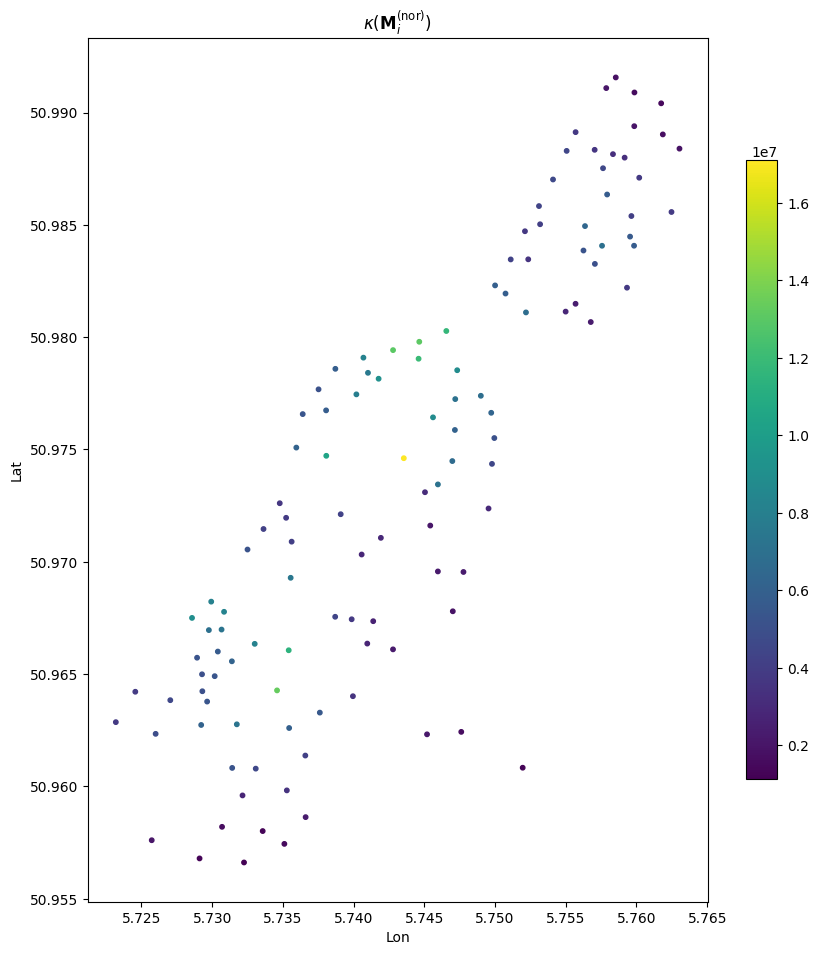

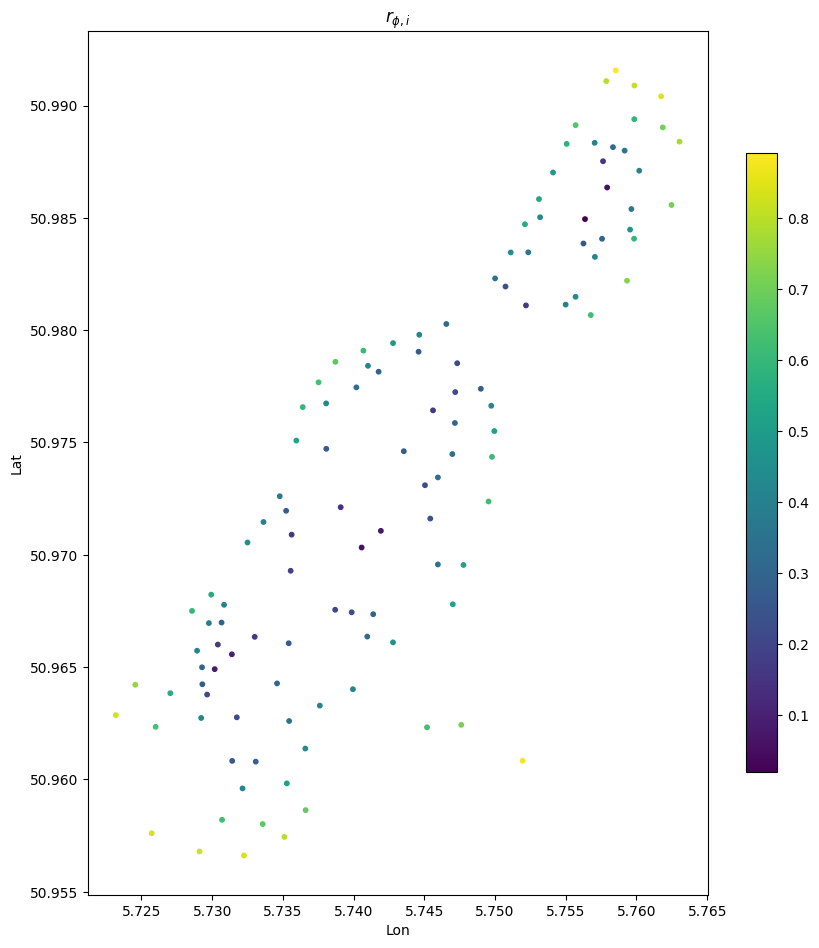

Saved:
 - section6_outputs/Appendix.Meuse.condM_nor.png
 - section6_outputs/Appendix.Meuse.r_phi.png


In [9]:
figure_specs = [
    (
        "condM_nor",
        r"$\kappa(\mathbf{M}_i^{(\mathrm{nor})})$",
        OUTPUT_DIR / "Appendix.Meuse.condM_nor.png",
    ),
    (
        "r_phi",
        r"$r_{\phi,i}$",
        OUTPUT_DIR / "Appendix.Meuse.r_phi.png",
    ),
]

for column, title, path in figure_specs:
    gr_local.draw_map(
        column=column,
        title=title,
        file_path=str(path),
        basemap=False,
        show=True,
    )

print("Saved:")
for _, _, path in figure_specs:
    print(" -", path)


These figures are descriptive. Neither diagnostic alone determines whether a local coefficient is substantively reliable, and the standardized benchmark conditioning results in Table 10 should not be conflated with the actual GR normal-matrix condition number shown in the first map.


## 6.4 Summary

A top-to-bottom run of this notebook generates the manuscript-facing Section 6 outputs:

- `table8_meuse_local_diagnostics.csv`
- `table9_meuse_benchmark.csv`
- `table10_meuse_conditioning.csv`
- `Appendix.Meuse.condM_nor.png`
- `Appendix.Meuse.r_phi.png`

Notebook tables are displayed to three decimal places to match the manuscript. CSV files retain six decimal places.

The two empirical protocols remain intentionally separate: Table 8 is descriptive and uses the fixed 120-location training sample, whereas Tables 9–10 use all 155 observations under five-fold cross-validation.
